# EB-NeRD Large Dataset — Dataset Analysis & Baseline Retrieval (A1)

**Course:** CS4.406 — Information Retrieval & Extraction (Assignment 1)  
**Dataset:** EB-NeRD (Ekstra Bladet News Recommendation Dataset) — RecSys 2024 Challenge  
**Goal:** Explore the large dataset, document available features, and generate Codabench submission predictions.

## Table of Contents
1. [Setup & Memory Strategy](#setup)
2. [Dataset Overview — What Files Exist](#overview)
3. [Articles — Full Feature Analysis](#articles)
4. [Behaviors (Train) — Click-Log Features](#behaviors-train)
5. [History — User Reading History](#history)
6. [Validation Set](#validation)
7. [Test Set — What's Different](#test)
8. [Feature Comparison: Train vs Test](#comparison)
9. [Generating Codabench Predictions](#predictions)

## 1. Setup & Memory Strategy

The large dataset has **12M+ behavior rows** and **1.2GB+ history files**. Loading these with pandas `read_parquet()` will exhaust typical RAM.

**Strategy:**
- **`polars`** with **lazy scanning** (`scan_parquet`) — processes data in chunks, only materializing what's needed.
- **`pyarrow.parquet.ParquetFile`** — reads schema/metadata without loading data at all.
- For the articles file (125K rows, ~150MB), direct read is fine.

In [1]:
import polars as pl
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Base paths
LARGE_DIR = Path("ebnerd_large")
TEST_DIR = Path("ebnerd_testset/ebnerd_testset")

print(f"Polars version: {pl.__version__}")
print(f"Large dataset dir: {LARGE_DIR}  (exists: {LARGE_DIR.exists()})")
print(f"Test dataset dir:  {TEST_DIR}  (exists: {TEST_DIR.exists()})")

Polars version: 1.43.2
Large dataset dir: ebnerd_large  (exists: True)
Test dataset dir:  ebnerd_testset/ebnerd_testset  (exists: True)


## 2. Dataset Overview — What Files Exist

The EB-NeRD large dataset is organized as:

```
ebnerd_large/
  articles.parquet          — 125,541 articles (metadata, text, sentiment, categories)
  train/
    behaviors.parquet       — 12,063,890 impression logs (click data)
    history.parquet         — 788,090 users' full reading history
  validation/
    behaviors.parquet       — 12,566,385 impression logs
    history.parquet         — 791,582 users' reading history

ebnerd_testset/ebnerd_testset/
  articles.parquet          — 125,541 articles (same as large)
  test/
    behaviors.parquet       — 13,536,710 impression logs (NO click labels!)
    history.parquet         — 807,677 users' reading history
```

**Key difference:** The test set has **no `article_ids_clicked` column** — that's what we need to predict.

In [2]:
# Read schemas without loading data — zero RAM cost
files = {
    "LARGE train/behaviors": LARGE_DIR / "train/behaviors.parquet",
    "LARGE train/history":   LARGE_DIR / "train/history.parquet",
    "LARGE val/behaviors":   LARGE_DIR / "validation/behaviors.parquet",
    "LARGE val/history":     LARGE_DIR / "validation/history.parquet",
    "LARGE articles":        LARGE_DIR / "articles.parquet",
    "TEST behaviors":        TEST_DIR / "test/behaviors.parquet",
    "TEST history":          TEST_DIR / "test/history.parquet",
    "TEST articles":         TEST_DIR / "articles.parquet",
}

schemas = {}
for label, path in files.items():
    pf = pq.ParquetFile(path)
    schemas[label] = {
        "rows": pf.metadata.num_rows,
        "cols": pf.metadata.num_columns,
        "row_groups": pf.metadata.num_row_groups,
        "schema": [(f.name, str(f.type)) for f in pf.schema_arrow],
    }
    print(f"=== {label} ===")
    print(f"  Rows: {pf.metadata.num_rows:,}  |  Cols: {pf.metadata.num_columns}  |  Row groups: {pf.metadata.num_row_groups}")
    for name, dtype in schemas[label]["schema"]:
        print(f"    {name}: {dtype}")
    print()

=== LARGE train/behaviors ===
  Rows: 12,063,890  |  Cols: 17  |  Row groups: 46
    impression_id: uint32
    article_id: int32
    impression_time: timestamp[us]
    read_time: float
    scroll_percentage: float
    device_type: int8
    article_ids_inview: large_list<item: int32>
    article_ids_clicked: large_list<item: int32>
    user_id: uint32
    is_sso_user: bool
    gender: int8
    postcode: int8
    age: int8
    is_subscriber: bool
    session_id: uint32
    next_read_time: float
    next_scroll_percentage: float

=== LARGE train/history ===
  Rows: 788,090  |  Cols: 5  |  Row groups: 5
    user_id: uint32
    impression_time_fixed: large_list<item: timestamp[us]>
    scroll_percentage_fixed: large_list<item: float>
    article_id_fixed: large_list<item: int32>
    read_time_fixed: large_list<item: float>

=== LARGE val/behaviors ===
  Rows: 12,566,385  |  Cols: 17  |  Row groups: 47
    impression_id: uint32
    article_id: int32
    impression_time: timestamp[us]
    rea

## 3. Articles — Full Feature Analysis

The articles file (125K rows) is small enough to load directly. It contains:

| Feature | Type | Description |
|---------|------|-------------|
| `article_id` | int32 | Unique article identifier |
| `title` | str | Article headline (Danish) |
| `subtitle` | str | Article subtitle/abstract |
| `body` | str | Full article body text |
| `last_modified_time` | datetime | Last modification timestamp |
| `published_time` | datetime | Publication timestamp |
| `premium` | bool | Whether article is behind paywall |
| `image_ids` | list[int64] | Associated image IDs (14K nulls) |
| `article_type` | str | 16 types (default, gallery, video, etc.) |
| `url` | str | Original article URL |
| `ner_clusters` | list[str] | Named entity recognition clusters |
| `entity_groups` | list[str] | Entity group labels (PER, LOC, ORG, etc.) |
| `topics` | list[str] | Topic tags (e.g., "Kriminalitet", "Sport") |
| `category` | int16 | Numeric category (32 unique) |
| `subcategory` | list[int16] | Subcategory codes |
| `category_str` | str | Human-readable category (e.g., "krimi", "sport") |
| `total_inviews` | int32 | Total impressions (85% null — only for recent articles) |
| `total_pageviews` | int32 | Total page views (87% null) |
| `total_read_time` | float | Total read time in seconds (87% null) |
| `sentiment_score` | float | Sentiment confidence (0.34–1.0) |
| `sentiment_label` | str | Positive / Negative / Neutral |

In [3]:
# Articles is small enough to load directly
articles = pl.read_parquet(LARGE_DIR / "articles.parquet")
print(f"Articles shape: {articles.shape}")
articles.head(5)

Articles shape: (125541, 21)


article_id,title,subtitle,last_modified_time,premium,body,published_time,image_ids,article_type,url,ner_clusters,entity_groups,topics,category,subcategory,category_str,total_inviews,total_pageviews,total_read_time,sentiment_score,sentiment_label
i32,str,str,datetime[μs],bool,str,datetime[μs],list[i64],str,str,list[str],list[str],list[str],i16,list[i16],str,i32,i32,f32,f32,str
3000022,"""Hanks beskyldt for mishandling""","""Tom Hanks har angiveligt misha…",2023-06-29 06:20:32,false,"""Tom Hanks skulle angiveligt ha…",2006-09-20 09:24:18,[3518381],"""article_default""","""https://ekstrabladet.dk/underh…","[""David Gardner""]","[""PER""]","[""Kriminalitet"", ""Kendt"", … ""Litteratur""]",414,[432],"""underholdning""",null,null,null,0.9911,"""Negative"""
3000063,"""Bostrups aske spredt i Furesøe…","""Studieværten blev mindet med g…",2023-06-29 06:20:32,false,"""Strålende sensommersol. Jazzed…",2006-09-24 07:45:30,"[3170935, 3170939]","""article_default""","""https://ekstrabladet.dk/nyhede…",[],[],"[""Kendt"", ""Underholdning"", … ""Personlig begivenhed""]",118,[133],"""nyheder""",null,null,null,0.5155,"""Neutral"""
3000613,"""Jesper Olsen ramt af hjerneblø…","""Den tidligere danske landshold…",2023-06-29 06:20:33,false,"""Jesper Olsen, der er noteret f…",2006-05-09 11:29:00,[3164998],"""article_default""","""https://ekstrabladet.dk/sport/…","[""Frankrig"", ""Jesper Olsen"", … ""Jesper Olsen""]","[""LOC"", ""PER"", … ""PER""]","[""Kendt"", ""Sport"", … ""Sygdom og behandling""]",142,"[196, 271]","""sport""",null,null,null,0.9876,"""Negative"""
3000700,"""Madonna topløs med heste""","""47-årige Madonna poserer både …",2023-06-29 06:20:33,false,"""Skal du have stillet Madonna-s…",2006-05-04 11:03:12,[3172046],"""article_default""","""https://ekstrabladet.dk/underh…",[],[],"[""Kendt"", ""Livsstil"", ""Underholdning""]",414,[432],"""underholdning""",null,null,null,0.8786,"""Neutral"""
3000840,"""Otto Brandenburg er død""","""Sangeren og skuespilleren Otto…",2023-06-29 06:20:33,false,"""'Og lidt for Susanne, Birgitte…",2007-03-01 18:34:00,[3914446],"""article_default""","""https://ekstrabladet.dk/nyhede…",[],[],"[""Kendt"", ""Underholdning"", … ""Musik og lyd""]",118,[133],"""nyheder""",null,null,null,0.9468,"""Negative"""


In [4]:
# Null counts per column
print("=== Null Counts ===")
for col in articles.columns:
    nulls = articles[col].null_count()
    pct = nulls / articles.height * 100
    print(f"  {col:25s}: {nulls:>7,} nulls ({pct:5.1f}%)")

=== Null Counts ===
  article_id               :       0 nulls (  0.0%)
  title                    :       0 nulls (  0.0%)
  subtitle                 :       0 nulls (  0.0%)
  last_modified_time       :       0 nulls (  0.0%)
  premium                  :       0 nulls (  0.0%)
  body                     :       0 nulls (  0.0%)
  published_time           :       0 nulls (  0.0%)
  image_ids                :  14,322 nulls ( 11.4%)
  article_type             :       0 nulls (  0.0%)
  url                      :       0 nulls (  0.0%)
  ner_clusters             :       0 nulls (  0.0%)
  entity_groups            :       0 nulls (  0.0%)
  topics                   :       0 nulls (  0.0%)
  category                 :       0 nulls (  0.0%)
  subcategory              :       0 nulls (  0.0%)
  category_str             :       0 nulls (  0.0%)
  total_inviews            : 107,205 nulls ( 85.4%)
  total_pageviews          : 108,600 nulls ( 86.5%)
  total_read_time          : 108,600 nulls (

In [5]:
# Article type distribution
print("=== Article Types ===")
print(articles["article_type"].value_counts().sort("count", descending=True))

print("\n=== Sentiment Labels ===")
print(articles["sentiment_label"].value_counts().sort("count", descending=True))

print("\n=== Premium (paywall) ===")
print(articles["premium"].value_counts())

print("\n=== Categories ===")
print(articles["category_str"].value_counts().sort("count", descending=True))

print(f"\n=== Published Time Range ===")
print(f"  From: {articles['published_time'].min()}  To: {articles['published_time'].max()}")

=== Article Types ===
shape: (16, 2)
┌──────────────────────────────┬────────┐
│ article_type                 ┆ count  │
│ ---                          ┆ ---    │
│ str                          ┆ u32    │
╞══════════════════════════════╪════════╡
│ article_default              ┆ 115251 │
│ article_video_standalone     ┆ 3923   │
│ article_page_nine_girl       ┆ 3583   │
│ article_scribblelive         ┆ 873    │
│ article_opinionen            ┆ 572    │
│ …                            ┆ …      │
│ article_native_feature       ┆ 15     │
│ article_image_gallery        ┆ 5      │
│ article_editorial_production ┆ 5      │
│ article_timeline             ┆ 1      │
│ article_accordion            ┆ 1      │
└──────────────────────────────┴────────┘

=== Sentiment Labels ===
shape: (3, 2)
┌─────────────────┬───────┐
│ sentiment_label ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ Negative        ┆ 61130 │
│ Neutral         ┆ 44001 │
│ Positive   

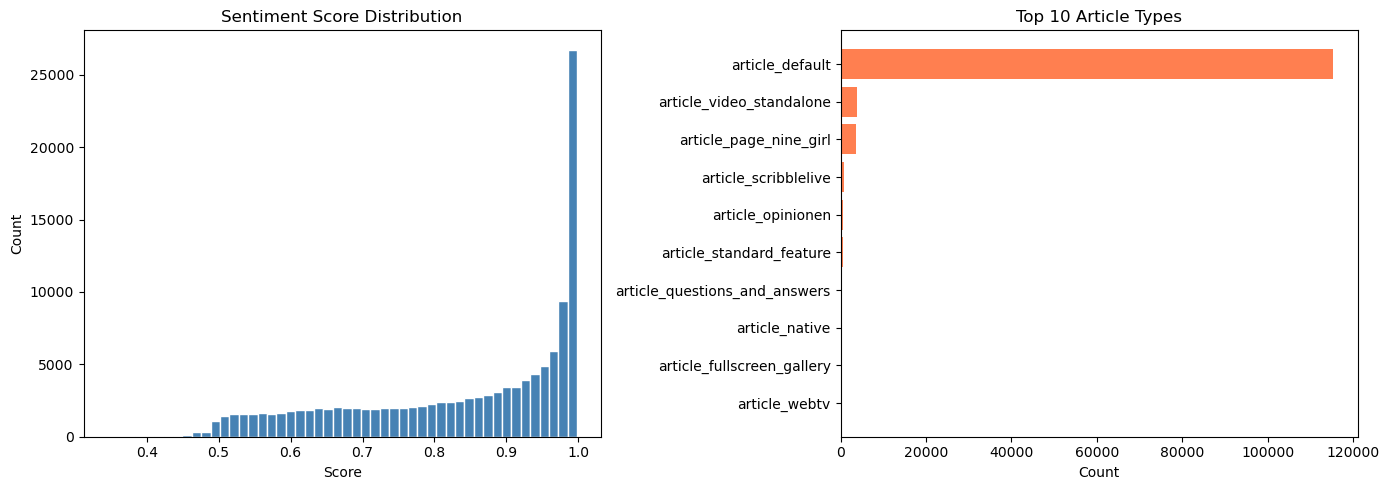

In [6]:
# Visualize sentiment score distribution and article type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment score histogram
axes[0].hist(articles["sentiment_score"].to_numpy(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Sentiment Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

# Article type (top 10)
type_counts = articles["article_type"].value_counts().sort("count", descending=True).head(10)
axes[1].barh(type_counts["article_type"].to_list(), type_counts["count"].to_list(), color="coral")
axes[1].set_title("Top 10 Article Types")
axes[1].invert_yaxis()
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 4. Behaviors (Train) — Click-Log Features

The behaviors file contains **12M+ impression logs** from 788K users over 1 week (May 18–25, 2023).

| Feature | Type | Description |
|---------|------|-------------|
| `impression_id` | uint32 | Unique impression ID |
| `article_id` | int32 | Article shown (null for non-click impressions — **70% null!**) |
| `impression_time` | datetime | When the impression occurred |
| `read_time` | float | Time spent reading (seconds) |
| `scroll_percentage` | float | How far user scrolled (0–100) |
| `device_type` | int8 | 1=mobile, 2=desktop, 3=tablet (inferred) |
| `article_ids_inview` | list[int32] | All articles visible in the impression |
| `article_ids_clicked` | list[int32] | Articles the user clicked (the label!) |
| `user_id` | uint32 | Anonymized user ID |
| `is_sso_user` | bool | Whether user is logged in (10.5% are) |
| `gender` | int8 | User gender (97% null — mostly anonymous) |
| `postcode` | int8 | Postal code (97% null) |
| `age` | int8 | User age (97% null) |
| `is_subscriber` | bool | Paywall subscriber (6.7%) |
| `session_id` | uint32 | Session identifier |
| `next_read_time` | float | Read time of next impression |
| `next_scroll_percentage` | float | Scroll % of next impression |

**Key observations:**
- `article_id` is null 70% of the time — it's only set when the user actually clicked
- `article_ids_inview` has 5–100 articles (avg ~11)
- `article_ids_clicked` has 1–10 articles (avg ~1)
- Demographic features (gender, postcode, age) are **97% null** — most users are anonymous

In [7]:
# Lazy scan — only materialize aggregated stats, not the full 12M rows
behaviors_lf = pl.scan_parquet(LARGE_DIR / "train/behaviors.parquet")

stats = behaviors_lf.select([
    pl.len().alias("total_rows"),
    pl.col("impression_id").n_unique().alias("unique_impressions"),
    pl.col("user_id").n_unique().alias("unique_users"),
    pl.col("session_id").n_unique().alias("unique_sessions"),
    pl.col("article_id").null_count().alias("null_article_id"),
    pl.col("read_time").null_count().alias("null_read_time"),
    pl.col("scroll_percentage").null_count().alias("null_scroll_pct"),
    pl.col("gender").null_count().alias("null_gender"),
    pl.col("postcode").null_count().alias("null_postcode"),
    pl.col("age").null_count().alias("null_age"),
    pl.col("is_sso_user").mean().alias("pct_sso"),
    pl.col("is_subscriber").mean().alias("pct_subscriber"),
    pl.col("impression_time").min().alias("min_time"),
    pl.col("impression_time").max().alias("max_time"),
    pl.col("article_ids_inview").list.len().mean().alias("avg_inview"),
    pl.col("article_ids_inview").list.len().min().alias("min_inview"),
    pl.col("article_ids_inview").list.len().max().alias("max_inview"),
    pl.col("article_ids_clicked").list.len().mean().alias("avg_clicked"),
    pl.col("article_ids_clicked").list.len().max().alias("max_clicked"),
]).collect()

print("=== Train Behaviors Summary ===")
for col in stats.columns:
    val = stats[col][0]
    if isinstance(val, float):
        print(f"  {col:25s}: {val:,.2f}")
    elif isinstance(val, int):
        print(f"  {col:25s}: {val:,}")
    else:
        print(f"  {col:25s}: {val}")

=== Train Behaviors Summary ===
  total_rows               : 12,063,890
  unique_impressions       : 12,063,890
  unique_users             : 788,090
  unique_sessions          : 6,227,464
  null_article_id          : 8,458,027
  null_read_time           : 0
  null_scroll_pct          : 8,523,902
  null_gender              : 11,176,907
  null_postcode            : 11,795,148
  null_age                 : 11,694,243
  pct_sso                  : 0.11
  pct_subscriber           : 0.07
  min_time                 : 2023-05-18 07:00:00
  max_time                 : 2023-05-25 06:59:59
  avg_inview               : 11.09
  min_inview               : 5
  max_inview               : 100
  avg_clicked              : 1.01
  max_clicked              : 10


In [8]:
# Sample 5 rows to see the actual data
behaviors_sample = behaviors_lf.head(5).collect()
behaviors_sample

impression_id,article_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,article_ids_clicked,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,next_read_time,next_scroll_percentage
u32,i32,datetime[μs],f32,f32,i8,list[i32],list[i32],u32,bool,i8,i8,i8,bool,u32,f32,f32
47727,null,2023-05-21 21:35:07,20.0,null,1,"[9482380, 9775183, … 9538375]",[9775183],18293,false,null,null,null,false,265,34.0,100.0
47731,null,2023-05-21 21:32:33,13.0,null,1,"[9774557, 9774516, … 9759966]",[9759966],18293,false,null,null,null,false,265,45.0,100.0
47736,null,2023-05-21 21:33:32,17.0,null,1,"[9759966, 9774557, … 9775323]",[9774652],18293,false,null,null,null,false,265,78.0,100.0
47737,null,2023-05-21 21:38:17,27.0,null,1,"[9774580, 9775131, … 9774899]",[9775184],18293,false,null,null,null,false,265,6.0,52.0
47740,null,2023-05-21 21:36:02,48.0,null,1,"[9774826, 9775171, … 9774648]",[9774648],18293,false,null,null,null,false,265,32.0,100.0


In [9]:
# Device type distribution (lazy aggregation)
device_dist = behaviors_lf.group_by("device_type").agg(
    pl.len().alias("count")
).sort("count", descending=True).collect()
print("=== Device Type Distribution ===")
print(device_dist)

# Click count distribution (how many articles clicked per impression)
click_dist = behaviors_lf.select(
    pl.col("article_ids_clicked").list.len().alias("n_clicked")
).group_by("n_clicked").agg(
    pl.len().alias("count")
).sort("n_clicked").collect()
print("\n=== Clicks per Impression ===")
print(click_dist)

=== Device Type Distribution ===
shape: (4, 2)
┌─────────────┬─────────┐
│ device_type ┆ count   │
│ ---         ┆ ---     │
│ i8          ┆ u32     │
╞═════════════╪═════════╡
│ 2           ┆ 7594061 │
│ 1           ┆ 4106838 │
│ 3           ┆ 362594  │
│ 0           ┆ 397     │
└─────────────┴─────────┘

=== Clicks per Impression ===
shape: (10, 2)
┌───────────┬──────────┐
│ n_clicked ┆ count    │
│ ---       ┆ ---      │
│ u32       ┆ u32      │
╞═══════════╪══════════╡
│ 1         ┆ 12004156 │
│ 2         ┆ 53705    │
│ 3         ┆ 3566     │
│ 4         ┆ 1258     │
│ 5         ┆ 597      │
│ 6         ┆ 358      │
│ 7         ┆ 209      │
│ 8         ┆ 28       │
│ 9         ┆ 11       │
│ 10        ┆ 2        │
└───────────┴──────────┘


## 5. History — User Reading History

The history file contains one row per user with their **full reading history** as parallel lists:

| Feature | Type | Description |
|---------|------|-------------|
| `user_id` | uint32 | User identifier |
| `impression_time_fixed` | list[datetime] | Timestamps of each historical impression |
| `scroll_percentage_fixed` | list[float] | Scroll depth for each impression |
| `article_id_fixed` | list[int32] | Article IDs the user interacted with |
| `read_time_fixed` | list[float] | Read time (seconds) for each article |

**Stats (train):** 788,090 users, avg 144 articles in history, max 1,530.

In [10]:
# History — lazy aggregation (the file is 1.2GB, do NOT load fully)
history_lf = pl.scan_parquet(LARGE_DIR / "train/history.parquet")

hist_stats = history_lf.select([
    pl.len().alias("total_users"),
    pl.col("article_id_fixed").list.len().mean().alias("avg_history_len"),
    pl.col("article_id_fixed").list.len().min().alias("min_history_len"),
    pl.col("article_id_fixed").list.len().max().alias("max_history_len"),
    pl.col("article_id_fixed").list.len().median().alias("median_history_len"),
]).collect()

print("=== Train History Summary ===")
for col in hist_stats.columns:
    val = hist_stats[col][0]
    if isinstance(val, float):
        print(f"  {col:25s}: {val:,.2f}")
    else:
        print(f"  {col:25s}: {val:,}")

# Sample 3 users
history_sample = history_lf.head(3).collect()
history_sample

=== Train History Summary ===
  total_users              : 788,090
  avg_history_len          : 158.84
  min_history_len          : 5
  max_history_len          : 2,696
  median_history_len       : 92.00


user_id,impression_time_fixed,scroll_percentage_fixed,article_id_fixed,read_time_fixed
u32,list[datetime[μs]],list[f32],list[i32],list[f32]
10029,"[2023-04-28 06:16:57, 2023-04-28 06:17:31, … 2023-05-18 06:59:50]","[23.0, 69.0, … null]","[9735579, 9739888, … 9770541]","[28.0, 24.0, … 0.0]"
10033,"[2023-04-27 11:11:32, 2023-04-27 11:12:56, … 2023-05-17 20:22:42]","[33.0, 41.0, … 29.0]","[9738139, 9738263, … 9769404]","[2.0, 2.0, … 1.0]"
10034,"[2023-04-30 09:46:57, 2023-04-30 09:47:33, … 2023-05-16 08:40:52]","[null, 88.0, … 100.0]","[9742693, 9742686, … 9767363]","[21.0, 103.0, … 9.0]"


## 6. Validation Set

The validation set mirrors the train set structure (same columns) but covers a different time period. It's used for offline evaluation before submitting to Codabench.

- **Behaviors:** 12,566,385 rows, 791,582 users
- **History:** 791,582 users with reading history
- Same 17 columns as train behaviors (including `article_ids_clicked`)

In [11]:
# Validation behaviors — lazy aggregation
val_beh_lf = pl.scan_parquet(LARGE_DIR / "validation/behaviors.parquet")
val_stats = val_beh_lf.select([
    pl.len().alias("total_rows"),
    pl.col("impression_id").n_unique().alias("unique_impressions"),
    pl.col("user_id").n_unique().alias("unique_users"),
    pl.col("impression_time").min().alias("min_time"),
    pl.col("impression_time").max().alias("max_time"),
    pl.col("article_ids_inview").list.len().mean().alias("avg_inview"),
    pl.col("article_ids_clicked").list.len().mean().alias("avg_clicked"),
]).collect()

print("=== Validation Behaviors Summary ===")
for col in val_stats.columns:
    val = val_stats[col][0]
    if isinstance(val, float):
        print(f"  {col:25s}: {val:,.2f}")
    elif isinstance(val, int):
        print(f"  {col:25s}: {val:,}")
    else:
        print(f"  {col:25s}: {val}")

=== Validation Behaviors Summary ===
  total_rows               : 12,566,385
  unique_impressions       : 12,566,385
  unique_users             : 791,582
  min_time                 : 2023-05-25 07:00:00
  max_time                 : 2023-06-01 06:59:59
  avg_inview               : 11.95
  avg_clicked              : 1.01


## 7. Test Set — What's Different

The test set is what we submit predictions for to **Codabench**. Key differences from train/validation:

### Features PRESENT in test behaviors:
| Feature | Available? |
|---------|-----------|
| `impression_id` | ✅ |
| `impression_time` | ✅ |
| `read_time` | ✅ |
| `scroll_percentage` | ✅ |
| `device_type` | ✅ |
| `article_ids_inview` | ✅ |
| `user_id` | ✅ |
| `is_sso_user` | ✅ |
| `gender` | ✅ (but 97% null) |
| `postcode` | ✅ (but 97% null) |
| `age` | ✅ (but 97% null) |
| `is_subscriber` | ✅ |
| `session_id` | ✅ |
| `is_beyond_accuracy` | ✅ (NEW — flag for beyond-accuracy evaluation) |

### Features MISSING from test behaviors:
| Feature | Reason |
|---------|--------|
| `article_id` | ❌ This was the clicked article — it's the label |
| `article_ids_clicked` | ❌ This is what we need to predict |
| `next_read_time` | ❌ Future information — not available at serving time |
| `next_scroll_percentage` | ❌ Future information |

### Test-specific feature:
- `is_beyond_accuracy` — 1.5% of impressions are flagged for beyond-accuracy evaluation (diversity, novelty, coverage metrics)

In [12]:
# Test behaviors — lazy aggregation
test_beh_lf = pl.scan_parquet(TEST_DIR / "test/behaviors.parquet")
test_stats = test_beh_lf.select([
    pl.len().alias("total_rows"),
    pl.col("impression_id").n_unique().alias("unique_impressions"),
    pl.col("user_id").n_unique().alias("unique_users"),
    pl.col("impression_time").min().alias("min_time"),
    pl.col("impression_time").max().alias("max_time"),
    pl.col("article_ids_inview").list.len().mean().alias("avg_inview"),
    pl.col("article_ids_inview").list.len().min().alias("min_inview"),
    pl.col("article_ids_inview").list.len().max().alias("max_inview"),
    pl.col("is_sso_user").mean().alias("pct_sso"),
    pl.col("is_subscriber").mean().alias("pct_subscriber"),
    pl.col("is_beyond_accuracy").mean().alias("pct_beyond_accuracy"),
    pl.col("gender").null_count().alias("null_gender"),
    pl.col("age").null_count().alias("null_age"),
]).collect()

print("=== Test Behaviors Summary ===")
for col in test_stats.columns:
    val = test_stats[col][0]
    if isinstance(val, float):
        print(f"  {col:25s}: {val:,.4f}")
    elif isinstance(val, int):
        print(f"  {col:25s}: {val:,}")
    else:
        print(f"  {col:25s}: {val}")

# Sample
test_sample = test_beh_lf.head(5).collect()
print("\n=== Test Sample ===")
test_sample

=== Test Behaviors Summary ===
  total_rows               : 13,536,710
  unique_impressions       : 13,336,711
  unique_users             : 807,677
  min_time                 : 2023-06-01 07:00:00
  max_time                 : 2023-06-08 06:59:59
  avg_inview               : 15.2124
  min_inview               : 5
  max_inview               : 250
  pct_sso                  : 0.1022
  pct_subscriber           : 0.0650
  pct_beyond_accuracy      : 0.0148
  null_gender              : 12,579,928
  null_age                 : 13,139,031

=== Test Sample ===


impression_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,is_beyond_accuracy
u32,datetime[μs],f32,f32,i8,list[i32],u32,bool,i8,i8,i8,bool,u32,bool
6451339,2023-06-05 15:02:49,8.0,null,2,"[9796527, 7851321, … 9492777]",35982,false,null,null,null,false,388,false
6451363,2023-06-05 15:03:56,20.0,null,2,"[9798532, 9791602, … 9798958]",36012,false,null,null,null,false,804,false
6451382,2023-06-05 15:25:53,9.0,null,2,"[9798498, 9793856, … 9798724]",36162,false,null,null,null,false,1528,false
6451383,2023-06-05 15:26:35,14.0,null,2,"[9797419, 9798829, … 9798805]",36162,false,null,null,null,false,1528,false
6451385,2023-06-05 15:26:14,8.0,null,2,"[9785014, 9798958, … 9486080]",36162,false,null,null,null,false,1528,false


## 8. Feature Comparison: Train vs Test

| Column | Train | Validation | Test |
|--------|:-----:|:----------:|:----:|
| impression_id | ✅ | ✅ | ✅ |
| article_id | ✅ | ✅ | ❌ |
| impression_time | ✅ | ✅ | ✅ |
| read_time | ✅ | ✅ | ✅ |
| scroll_percentage | ✅ | ✅ | ✅ |
| device_type | ✅ | ✅ | ✅ |
| article_ids_inview | ✅ | ✅ | ✅ |
| article_ids_clicked | ✅ | ✅ | ❌ |
| user_id | ✅ | ✅ | ✅ |
| is_sso_user | ✅ | ✅ | ✅ |
| gender | ✅ | ✅ | ✅ |
| postcode | ✅ | ✅ | ✅ |
| age | ✅ | ✅ | ✅ |
| is_subscriber | ✅ | ✅ | ✅ |
| session_id | ✅ | ✅ | ✅ |
| next_read_time | ✅ | ✅ | ❌ |
| next_scroll_percentage | ✅ | ✅ | ❌ |
| is_beyond_accuracy | ❌ | ❌ | ✅ |

**Summary:** Test has 14 columns vs train's 17. The 3 missing columns are the label (`article_id`, `article_ids_clicked`) and future info (`next_*`). Test adds `is_beyond_accuracy`.

In [13]:
# Side-by-side column comparison
train_cols = set(schemas["LARGE train/behaviors"]["schema"])
val_cols = set(schemas["LARGE val/behaviors"]["schema"])
test_cols = set(schemas["TEST behaviors"]["schema"])

print("Columns in train but NOT in test:")
for col in sorted(train_cols - test_cols):
    print(f"  - {col[0]} ({col[1]})")

print("\nColumns in test but NOT in train:")
for col in sorted(test_cols - train_cols):
    print(f"  - {col[0]} ({col[1]})")

print("\nColumns in both:")
for col in sorted(train_cols & test_cols):
    print(f"  - {col[0]}")

Columns in train but NOT in test:
  - article_id (int32)
  - article_ids_clicked (large_list<item: int32>)
  - next_read_time (float)
  - next_scroll_percentage (float)

Columns in test but NOT in train:
  - is_beyond_accuracy (bool)

Columns in both:
  - age
  - article_ids_inview
  - device_type
  - gender
  - impression_id
  - impression_time
  - is_sso_user
  - is_subscriber
  - postcode
  - read_time
  - scroll_percentage
  - session_id
  - user_id


## 9. Generating Codabench Predictions

The submission format is a text file where each line is:

```
impression_id [rank_order]
```

Example: `6451339 [8,1,6,7,4,2,9,5,3]`

The `[rank_order]` is a permutation of 1..N where N = number of articles in `article_ids_inview` for that impression. Rank 1 = most likely to be clicked.

**Strategy:** We'll use a popularity-based baseline (most-clicked articles first) as a starting point. This can be improved with:
- Content-based features (title/category similarity to user history)
- Collaborative filtering
- GBDT re-ranker (LightGBM/XGBoost) over engineered features
- Neural ranker (NRMS-style)

The prediction file must cover **all unique impression_ids** in the test set.

In [14]:
# Step 1: Compute article popularity from train behaviors (lazy scan)
# Count how many times each article was clicked across all training impressions

train_beh_lf = pl.scan_parquet(LARGE_DIR / "train/behaviors.parquet")

# Explode article_ids_clicked and count occurrences
article_popularity = (
    train_beh_lf
    .select(pl.col("article_ids_clicked"))
    .explode("article_ids_clicked")
    .rename({"article_ids_clicked": "article_id"})
    .group_by("article_id")
    .agg(pl.len().alias("click_count"))
    .sort("click_count", descending=True)
    .collect()
)

print(f"Unique articles clicked in train: {article_popularity.height:,}")
print(f"Top 10 most clicked articles:")
print(article_popularity.head(10))

Unique articles clicked in train: 4,766
Top 10 most clicked articles:
shape: (10, 2)
┌────────────┬─────────────┐
│ article_id ┆ click_count │
│ ---        ┆ ---         │
│ i32        ┆ u32         │
╞════════════╪═════════════╡
│ 9771627    ┆ 70080       │
│ 9771113    ┆ 61010       │
│ 9774532    ┆ 56402       │
│ 9768308    ┆ 50268       │
│ 9770028    ┆ 48844       │
│ 9769917    ┆ 48707       │
│ 9772453    ┆ 47397       │
│ 9769504    ┆ 44349       │
│ 9773846    ┆ 43921       │
│ 9772635    ┆ 43132       │
└────────────┴─────────────┘


/tmp/ipykernel_36422/2053085035.py:10: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("article_ids_clicked")


In [15]:
# Step 2: Build popularity lookup as a dict for fast scoring
popularity_dict = dict(zip(
    article_popularity["article_id"].to_list(),
    article_popularity["click_count"].to_list()
))
max_pop = max(popularity_dict.values())
print(f"Max click count for any article: {max_pop:,}")
print(f"Articles with popularity data: {len(popularity_dict):,}")

Max click count for any article: 70,080
Articles with popularity data: 4,766


In [16]:
# Step 3: Generate predictions for the test set (BATCHED + VECTORIZED)
# Process one parquet row group at a time to keep memory low.
# Each row group: ~265K rows × ~11 inview = ~3M exploded rows = ~120MB. Safe.

import pyarrow.parquet as pq
import gc

OUTPUT_FILE = "predictions.txt"
TEST_BEHAVIORS = TEST_DIR / "test/behaviors.parquet"

pf = pq.ParquetFile(TEST_BEHAVIORS)
n_row_groups = pf.metadata.num_row_groups
print(f"Processing {n_row_groups} row groups (vectorized, batched)...")

predictions_written = 0

with open(OUTPUT_FILE, "w") as f:
    for rg_idx in range(n_row_groups):
        batch = pl.from_arrow(pf.read_row_group(rg_idx))

        # Vectorized: explode inview list, join popularity, rank, regroup
        scored = (
            batch
            .select("impression_id", "article_ids_inview")
            .with_columns(pl.int_ranges(0, pl.col("article_ids_inview").list.len()).alias("pos"))
            .explode(["article_ids_inview", "pos"])
            .rename({"article_ids_inview": "article_id"})
            .join(article_popularity, on="article_id", how="left")
            .with_columns(pl.col("click_count").fill_null(0))
            .sort(["impression_id", "pos"])
            .with_columns(
                pl.col("click_count")
                .rank(method="ordinal", descending=True)
                .over("impression_id")
                .alias("rank")
            )
            .sort(["impression_id", "pos"])
            .group_by("impression_id")
            .agg(pl.col("rank").alias("rank_order"))
            .sort("impression_id")
        )

        # Write results
        for imp_id, ranks in zip(scored["impression_id"].to_list(), scored["rank_order"].to_list()):
            f.write(f"{imp_id} [{','.join(map(str, ranks))}]\n")
        predictions_written += scored.height

        # Free memory between batches
        del batch, scored
        gc.collect()

        if (rg_idx + 1) % 10 == 0:
            print(f"  Row group {rg_idx + 1}/{n_row_groups}, {predictions_written:,} predictions written")

print(f"\nDone! {predictions_written:,} predictions written to {OUTPUT_FILE}")


Processing 51 row groups (vectorized, batched)...


/tmp/ipykernel_36422/223550613.py:26: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode(["article_ids_inview", "pos"])


  Row group 10/51, 2,654,250 predictions written


  Row group 20/51, 5,308,500 predictions written


  Row group 30/51, 7,962,750 predictions written


  Row group 40/51, 10,617,000 predictions written


  Row group 50/51, 13,271,250 predictions written



Done! 13,336,711 predictions written to predictions.txt


In [17]:
# Verify the output format matches the expected Codabench format
print("=== First 5 lines of predictions.txt ===")
with open(OUTPUT_FILE, "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

# Compare with the sample predictions
print("\n=== Sample from predictions_large_random (reference) ===")
with open("predictions_large_random/predictions.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

=== First 5 lines of predictions.txt ===
6451339 [4,3,5,6,1,7,8,9,2]
6451363 [1,2,3,4,5,6,7,8]
6451382 [1,2,3,4,5]
6451383 [3,4,2,5,6,7,1,8,9,10,11]
6451385 [2,3,4,5,6,7,1]

=== Sample from predictions_large_random (reference) ===
6451339 [8,1,6,7,4,2,9,5,3]
6451363 [5,4,3,7,6,8,1,2]
6451382 [1,5,3,4,2]
6451383 [7,6,8,9,3,4,2,11,10,1,5]
6451385 [5,3,2,4,7,6,1]


In [18]:
# Step 4: Zip the predictions for Codabench upload
import zipfile

ZIP_FILE = "predictions.zip"
with zipfile.ZipFile(ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(OUTPUT_FILE)

zip_size = Path(ZIP_FILE).stat().st_size
print(f"Created {ZIP_FILE} ({zip_size / 1e6:.1f} MB)")
print(f"\nUpload {ZIP_FILE} to: https://www.codabench.org/competitions/2469/")

Created predictions.zip (199.5 MB)

Upload predictions.zip to: https://www.codabench.org/competitions/2469/


## Summary & Next Steps

### What we found in the large dataset:

- **Articles (125K):** Rich metadata — title, subtitle, body, NER, topics, categories, sentiment, popularity stats. 85%+ of articles lack `total_inviews`/`total_pageviews` (only recent articles have them).
- **Behaviors (12M train):** Click logs with 17 columns. 70% of `article_id` is null (non-click impressions). Demographics (gender, age, postcode) are 97% null. Avg 11 articles in view, avg 1 clicked.
- **History (788K users):** Full reading history per user, avg 144 articles. Useful for building user profiles and recency-weighted features.
- **Test set (13.5M):** 14 columns — missing `article_id`, `article_ids_clicked`, `next_*` (the labels and future info). Adds `is_beyond_accuracy` flag.

### Prediction baseline (A1):
- Popularity-based ranking (most-clicked articles first) as a starting baseline
- Output format: `impression_id [rank_order]` — a permutation of 1..N per impression
- Zip and upload to Codabench

### Next steps for A1:
1. **BM25 lexical retrieval:** Build inverted index over article titles/abstracts, retrieve top-K candidates using user history as query
2. **Embedding-based semantic retrieval:** Load/compute article embeddings, build ANN index, mean-pool user history for user representation
3. **Evaluation harness:** Implement AUC, MRR, nDCG@5, nDCG@10, plus diversity/novelty/coverage with bootstrap CIs
4. **Recall@K analysis:** Compare lexical vs semantic retrieval for K in {50, 100, 200}
5. **Slicing:** Cold-start vs warm users, head vs tail articles
